In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
Clean_transactions = pd.read_csv(
    "../data/clean/cleaned_transactions.csv",
    parse_dates=["transaction_date", "signup_date"]
)

Clean_transactions.head()

,order_id,customer_id,transaction_date,product_category,quantity,unit_price,revenue,signup_date,acquisition_channel,country,TransactionMonth,Year,Month,DayOfWeek,Quarter,cohort_month
0,ORD0000001,CUST000001,2023-05-24,Fashion,4,144.98,579.92,2023-04-13,Instagram,Canada,2023-05,2023,5,Wednesday,2,2023-05
1,ORD0000002,CUST000002,2024-03-18,Beauty,3,28.21,84.63,2024-03-11,Email,USA,2024-03,2024,3,Monday,1,2024-03
2,ORD0000003,CUST000002,2024-04-09,Beauty,4,24.68,98.72,2024-03-11,Email,USA,2024-04,2024,4,Tuesday,2,2024-03
3,ORD0000004,CUST000002,2024-05-05,Fashion,2,35.77,71.54,2024-03-11,Email,USA,2024-05,2024,5,Sunday,2,2024-03
4,ORD0000005,CUST000002,2024-06-20,Sports,2,19.67,39.34,2024-03-11,Email,USA,2024-06,2024,6,Thursday,2,2024-03


In [17]:
Clean_transactions["country"].unique()

array(['Canada', 'USA', 'France', 'Germany', 'UK', 'Australia'],
      dtype=object)

Exploring customer segment

In [3]:
Clean_transactions["acquisition_channel"].value_counts()

acquisition_channel
Instagram         10682
Direct            10312
Referral          10288
Organic Search    10245
Google Ads        10191
Facebook Ads      10115
Email              9939
Name: count, dtype: int64

In [4]:
Clean_transactions["country"].value_counts()

country
Australia    12369
Germany      12214
Canada       11948
USA          11852
France       11757
UK           11632
Name: count, dtype: int64

Calculate Average Order Value (AOV)

In [5]:
Average_Order_Value = (
    Clean_transactions.groupby("acquisition_channel")
      .agg(
          total_revenue=("revenue", "sum"),
          total_orders=("order_id", "nunique")
      )
)

Average_Order_Value["AOV"] = (
    Average_Order_Value["total_revenue"] /
    Average_Order_Value["total_orders"]
)

Average_Order_Value

,total_revenue,total_orders,AOV
acquisition_channel,,,
Direct,3350333.47,10312,324.896574
Email,3241572.78,9939,326.146773
Facebook Ads,3284639.73,10115,324.729583
Google Ads,3297271.96,10191,323.547440
Instagram,3460426.96,10682,323.949350
Organic Search,3321020.31,10245,324.160108
Referral,3307095.45,10288,321.451735


Calculate Purchase Frequency

In [6]:
purchase_frequency = (
    Clean_transactions.groupby("acquisition_channel")
      .agg(
          total_orders=("order_id", "nunique"),
          unique_customers=("customer_id", "nunique")
      )
)

purchase_frequency["Purchase_Frequency"] = (
    purchase_frequency["total_orders"] /
    purchase_frequency["unique_customers"]
)

purchase_frequency

,total_orders,unique_customers,Purchase_Frequency
acquisition_channel,,,
Direct,10312,2747,3.753913
Email,9939,2674,3.716904
Facebook Ads,10115,2699,3.747684
Google Ads,10191,2675,3.809720
Instagram,10682,2781,3.841064
Organic Search,10245,2703,3.790233
Referral,10288,2797,3.678227


Calculate Historical CLTV

In [7]:
Cust_lifetime_Value = Average_Order_Value.join(
    purchase_frequency[["Purchase_Frequency"]]
)

Cust_lifetime_Value["Historical_CLTV"] = (
    Cust_lifetime_Value["AOV"] *
    Cust_lifetime_Value["Purchase_Frequency"]
)

Cust_lifetime_Value

,total_revenue,total_orders,AOV,Purchase_Frequency,Historical_CLTV
acquisition_channel,,,,,
Direct,3350333.47,10312,324.896574,3.753913,1219.633589
Email,3241572.78,9939,326.146773,3.716904,1212.256088
Facebook Ads,3284639.73,10115,324.729583,3.747684,1216.983968
Google Ads,3297271.96,10191,323.547440,3.809720,1232.625032
Instagram,3460426.96,10682,323.949350,3.841064,1244.310306
Organic Search,3321020.31,10245,324.160108,3.790233,1228.642364
Referral,3307095.45,10288,321.451735,3.678227,1182.372345


Segment Customers by Country

In [8]:
country_summary = (
    Clean_transactions.groupby("country")
      .agg(
          Revenue=("revenue", "sum"),
          Customers=("customer_id", "nunique"),
          Orders=("order_id", "nunique")
      )
)

country_summary["AOV"] = (
    country_summary["Revenue"] /
    country_summary["Orders"]
)

country_summary["Purchase_Frequency"] = (
    country_summary["Orders"] /
    country_summary["Customers"]
)

country_summary["Historical_CLTV"] = (
    country_summary["AOV"] *
    country_summary["Purchase_Frequency"]
)

country_summary

,Revenue,Customers,Orders,AOV,Purchase_Frequency,Historical_CLTV
country,,,,,,
Australia,3991463.35,3233,12369,322.698953,3.825858,1234.600479
Canada,3923367.40,3242,11948,328.370221,3.685379,1210.168846
France,3826265.51,3119,11757,325.445735,3.769477,1226.760343
Germany,3939101.01,3249,12214,322.507042,3.759311,1212.404127
UK,3714941.72,3118,11632,319.372569,3.730597,1191.450199
USA,3867221.67,3115,11852,326.292750,3.804815,1241.483682


Identify High-Value Customer Segments

In [9]:
Cust_lifetime_Value.sort_values(
    by="Historical_CLTV",
    ascending=False
)

,total_revenue,total_orders,AOV,Purchase_Frequency,Historical_CLTV
acquisition_channel,,,,,
Instagram,3460426.96,10682,323.949350,3.841064,1244.310306
Google Ads,3297271.96,10191,323.547440,3.809720,1232.625032
Organic Search,3321020.31,10245,324.160108,3.790233,1228.642364
Direct,3350333.47,10312,324.896574,3.753913,1219.633589
Facebook Ads,3284639.73,10115,324.729583,3.747684,1216.983968
Email,3241572.78,9939,326.146773,3.716904,1212.256088
Referral,3307095.45,10288,321.451735,3.678227,1182.372345


In [10]:
#For Countries 
country_summary.sort_values(
    by="Historical_CLTV",
    ascending=False
)

,Revenue,Customers,Orders,AOV,Purchase_Frequency,Historical_CLTV
country,,,,,,
USA,3867221.67,3115,11852,326.292750,3.804815,1241.483682
Australia,3991463.35,3233,12369,322.698953,3.825858,1234.600479
France,3826265.51,3119,11757,325.445735,3.769477,1226.760343
Germany,3939101.01,3249,12214,322.507042,3.759311,1212.404127
Canada,3923367.40,3242,11948,328.370221,3.685379,1210.168846
UK,3714941.72,3118,11632,319.372569,3.730597,1191.450199


In [11]:
Cust_lifetime_Value.to_csv(
    "../data/CTLV_analysis/cltv_summary.csv"
)

In [12]:
country_summary.to_csv(
    "../data/CTLV_analysis/customer_segments.csv"
)

Create Visualizations

CLTV by Acquisition Channel

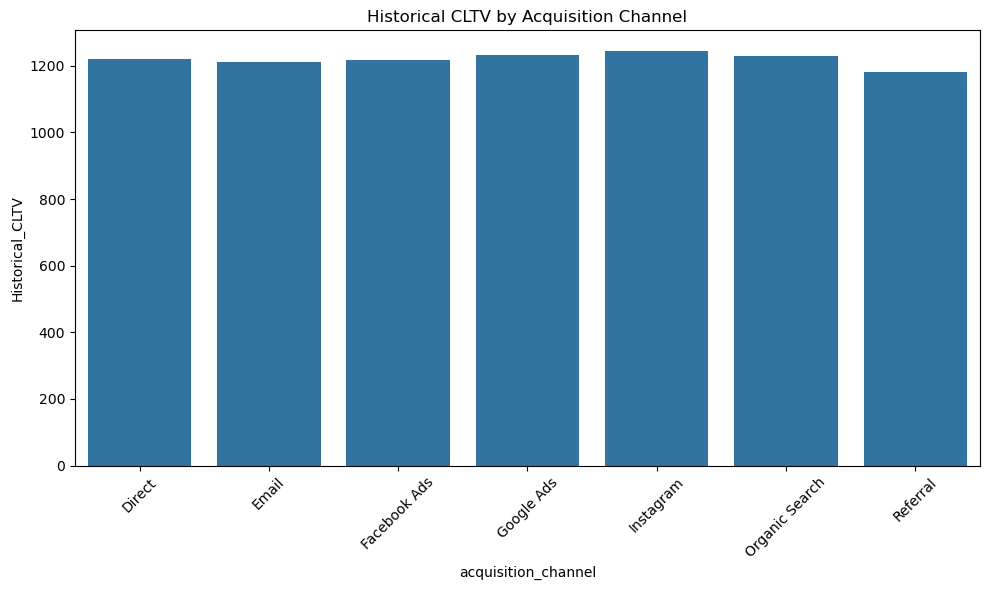

In [13]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=Cust_lifetime_Value.reset_index(),
    x="acquisition_channel",
    y="Historical_CLTV"
)

plt.title("Historical CLTV by Acquisition Channel")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../visuals/cltv_by_channel.png",
    dpi=300
)

plt.show()

C:\Users\NNEKA AKANNO\AppData\Local\Temp\ipykernel_25060\2135769853.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


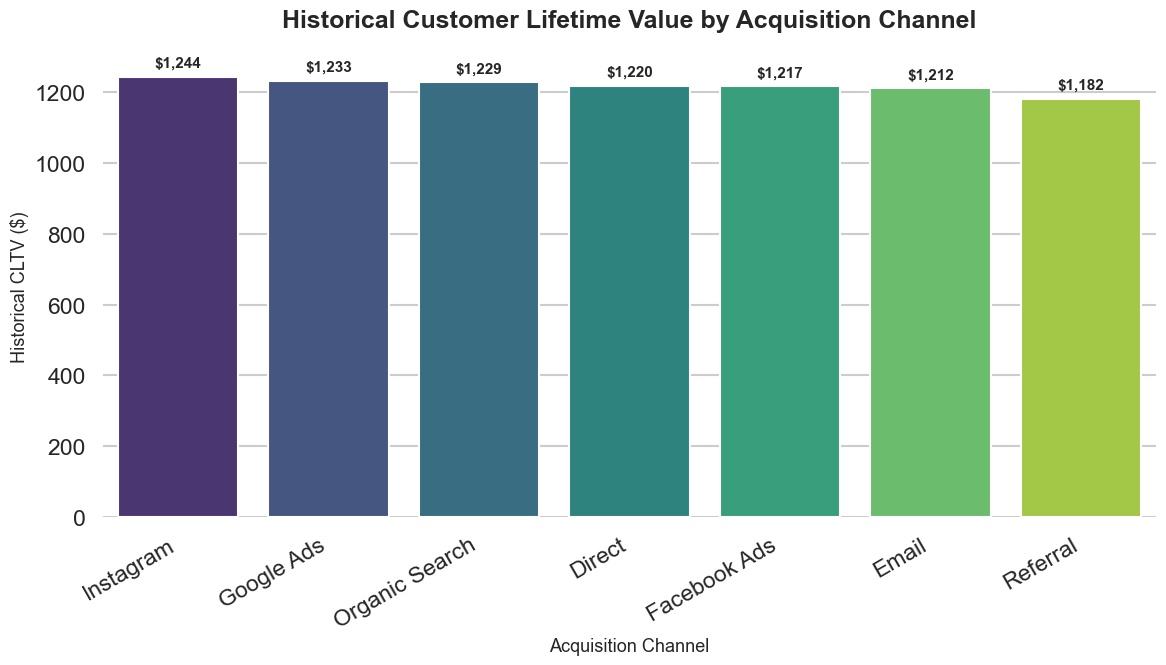

In [14]:

# Style
sns.set_theme(style="whitegrid", context="talk")

# Prepare data
Cust_lifetime_Value = (
    Cust_lifetime_Value.reset_index()
    .sort_values("Historical_CLTV", ascending=False)
)

# Create figure
plt.figure(figsize=(12, 7))

# Bar plot
ax = sns.barplot(
    data=Cust_lifetime_Value,
    x="acquisition_channel",
    y="Historical_CLTV",
    palette="viridis"
)

# Add value labels
for p in ax.patches:
    ax.annotate(
        f"${p.get_height():,.0f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        xytext=(0, 5),
        textcoords="offset points"
    )

# Formatting
ax.set_title(
    "Historical Customer Lifetime Value by Acquisition Channel",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("Acquisition Channel", fontsize=13)
ax.set_ylabel("Historical CLTV ($)", fontsize=13)

plt.xticks(rotation=30, ha="right")

# Remove unnecessary borders
sns.despine(left=True, bottom=True)

plt.tight_layout()

# Save
plt.savefig(
    "../visuals/cltv_by_channel.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

CLTV by Country

C:\Users\NNEKA AKANNO\AppData\Local\Temp\ipykernel_25060\429799141.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


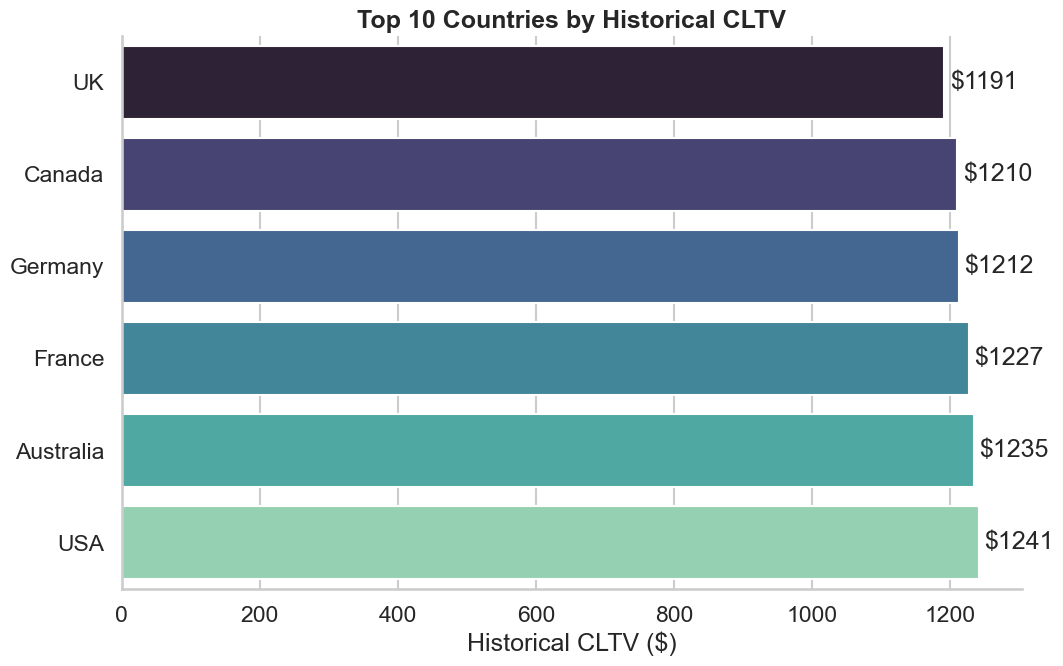

In [19]:
top_country = (
    country_summary.reset_index()
    .nlargest(10, "Historical_CLTV")
    .sort_values("Historical_CLTV")
)

plt.figure(figsize=(11, 7))

ax = sns.barplot(
    data=top_country,
    y="country",
    x="Historical_CLTV",
    palette="mako"
)

for container in ax.containers:
    ax.bar_label(container, fmt="$%.0f", padding=4)

ax.set_title(
    "Top 10 Countries by Historical CLTV",
    fontsize=18,
    weight="bold"
)

ax.set_xlabel("Historical CLTV ($)")
ax.set_ylabel("")

sns.despine()
plt.tight_layout()

plt.savefig(
    "../visuals/top10_cltv_by_country.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()